In [1]:
import fastf1 as ff1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from fastf1 import plotting
from scipy import stats

ff1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme="fastf1")
np.random.seed(123)

%matplotlib widget

In [2]:
TEAM_1 = "McLaren"
TEAM_2 = "Red Bull Racing"

In [3]:
def shapiro_wilk_test(data: pd.Series, alpha: float = 0.05) -> bool:
    statistic, p_value = stats.shapiro(data)

    print(f"Test stastic {statistic:.4f}")
    print(f"P-Value {p_value:.4f}")

    if p_value > alpha:
        print("The data looks normally distributed")
        return True
    print("The data does NOT look normally distributed.")
    return False

In [4]:
def mann_whitney_u_test(series1: pd.Series, series2: pd.Series, alpha: float = 0.05) -> bool:
    statistic, p_value = stats.mannwhitneyu(series1, series2, alternative="two-sided")

    print(f"Test stastic {statistic:.4f}")
    print(f"P-Value {p_value:.4f}")

    if p_value > alpha:
        print("There IS a statistical statistically significant difference between the two series.")
        return True
    print("There is NOT a statistical statistically significant difference between the two series.")
    return False

In [5]:
def plot_normality_visual_inspection(data: pd.Series) -> None:
    _, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.histplot(data, kde=True, ax=axes[0], color="blue")
    axes[0].set_title("Histogram")

    stats.probplot(data, dist="norm", plot=axes[1])
    axes[1].set_title("Q-Q Plot")

    plt.tight_layout()
    plt.show()

In [6]:
def ks_test(series_a: pd.Series, series_b: pd.Series, alpha=0.05):
    """Perform a Two-Sample Kolmogorov-Smirnov test."""

    a_clean = pd.Series(series_a).dropna()
    b_clean = pd.Series(series_b).dropna()

    statistic, p_value = stats.ks_2samp(a_clean, b_clean)

    print(f"D-Statistic (Max gap between distributions): {statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")

    if p_value < alpha:
        print("Conclusion: The distributions are statistically DIFFERENT (Reject Null).")
    else:
        print("Conclusion: No significant difference in distributions (Fail to Reject Null).")

    return statistic, p_value

In [7]:
def plot_laptime_distribution_by_team_with_tyre_life(data: pd.DataFrame, session) -> None:
    median_order = data.groupby("Team")["LapTime(s)"].median().sort_values().index
    team_palette = {team: ff1.plotting.get_team_color(team, session=session) for team in median_order}

    bins = [-1, 5, 10, 15, 20, 25]
    labels = ["0-5", "6-10", "11-15", "16-20", "21-25"]

    data["TyreLifeCat"] = pd.cut(data["TyreLife"], bins=bins, labels=labels)

    fig, ax = plt.subplots(figsize=(18, 5))

    sns.violinplot(
        data=data,
        x="Team",
        y="LapTime(s)",
        hue="Team",
        inner=None,
        density_norm="area",
        order=median_order,
        palette=team_palette,
    )

    sns.swarmplot(
        data=data,
        x="Team",
        y="LapTime(s)",
        order=median_order,
        hue="TyreLifeCat",
        palette="Greys",
        linewidth=0.5,
        edgecolor="gray",
        size=4,
    )

    plt.legend(title="Tyre Life (Laps)", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.title("Lap Time Distribution by Team (Shaded by Tyre Life)")
    plt.tight_layout()
    plt.show()

In [8]:
ff1.get_event(2025, 23)

req         WARNING 	DEFAULT CACHE ENABLED! (1.43 GB) C:\Users\Vitor\AppData\Local\Temp\fastf1


RoundNumber                                                     23
Country                                                      Qatar
Location                                                    Lusail
OfficialEventName    FORMULA 1 QATAR AIRWAYS QATAR GRAND PRIX 2025
EventDate                                      2025-11-30 00:00:00
EventName                                         Qatar Grand Prix
EventFormat                                      sprint_qualifying
Session1                                                Practice 1
Session1Date                             2025-11-28 16:30:00+03:00
Session1DateUtc                                2025-11-28 13:30:00
Session2                                         Sprint Qualifying
Session2Date                             2025-11-28 20:30:00+03:00
Session2DateUtc                                2025-11-28 17:30:00
Session3                                                    Sprint
Session3Date                             2025-11-29 17:00:00+0

In [9]:
fp1 = ff1.get_session(2025, 23, "FP1")
sq = ff1.get_session(2025, 23, "SQ")
sprint = ff1.get_session(2025, 23, "S")
quali = ff1.get_session(2025, 23, "Q")
fp1.load()
sq.load()
sprint.load()
quali.load()

core           INFO 	Loading data for Qatar Grand Prix - Practice 1 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '5', '6', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '43', '44', '55', '63', '81', '87']
core           INFO 	Loading data for Qatar Grand Prix - Sprint Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	Sprint Qualifying is not supported by Ergast! Limited results are calculated from timing data.
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing tim

In [10]:
fp1_push_laps = fp1.laps.pick_quicklaps()
sq_push_laps = sq.laps.pick_quicklaps()
sprint_push_laps = sprint.laps.pick_quicklaps()
quali_push_laps = quali.laps.pick_quicklaps()

In [11]:
all_laps = pd.concat([
    fp1_push_laps.assign(Session="FP1"),
    sq_push_laps.assign(Session="SQ"),
    sprint_push_laps.assign(Session="Sprint"),
    quali_push_laps.assign(Session="Quali"),
], ignore_index=True)

In [12]:
all_laps["LapTime(s)"] = all_laps["LapTime"].dt.total_seconds()

In [13]:
all_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,Session,LapTime(s)
0,0 days 00:13:57.430000,VER,1,0 days 00:01:25.047000,2.0,1.0,NaT,NaT,0 days 00:00:31.355000,0 days 00:00:28.800000,...,0 days 00:12:32.383000,2025-11-28 13:32:15.886,1,NaN,False,,False,True,FP1,85.047
1,0 days 00:17:38.470000,VER,1,0 days 00:01:23.343000,4.0,1.0,NaT,NaT,0 days 00:00:30.497000,0 days 00:00:28.417000,...,0 days 00:16:15.127000,2025-11-28 13:35:58.630,1,NaN,False,,False,True,FP1,83.343
2,0 days 00:27:38.002000,VER,1,0 days 00:01:22.372000,9.0,1.0,NaT,NaT,0 days 00:00:30.134000,0 days 00:00:28.145000,...,0 days 00:26:15.630000,2025-11-28 13:45:59.133,1,NaN,False,,False,True,FP1,82.372
3,0 days 00:39:50.631000,VER,1,0 days 00:01:26.510000,12.0,2.0,NaT,NaT,0 days 00:00:31.817000,0 days 00:00:29.391000,...,0 days 00:38:24.121000,2025-11-28 13:58:07.624,1,NaN,False,,False,True,FP1,86.510
4,0 days 00:41:16.927000,VER,1,0 days 00:01:26.296000,13.0,2.0,NaT,NaT,0 days 00:00:31.797000,0 days 00:00:29.355000,...,0 days 00:39:50.631000,2025-11-28 13:59:34.134,1,NaN,False,,False,True,FP1,86.296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,0 days 00:26:12.463000,STR,18,0 days 00:01:21.249000,7.0,2.0,NaT,NaT,0 days 00:00:29.921000,0 days 00:00:27.496000,...,0 days 00:24:51.214000,2025-11-29 18:13:14.911,1,NaN,False,,False,True,Quali,81.249
790,0 days 00:29:41.313000,STR,18,0 days 00:01:21.058000,9.0,2.0,NaT,NaT,0 days 00:00:29.782000,0 days 00:00:27.505000,...,0 days 00:28:20.255000,2025-11-29 18:16:43.952,1,NaN,False,,False,True,Quali,81.058
791,0 days 00:16:42.001000,COL,43,0 days 00:01:22.080000,2.0,1.0,NaT,NaT,0 days 00:00:30.225000,0 days 00:00:27.743000,...,0 days 00:15:19.921000,2025-11-29 18:03:43.618,1,NaN,True,TRACK LIMITS AT TURN 15 LAP 3,False,True,Quali,82.080
792,0 days 00:22:04.364000,COL,43,0 days 00:01:22.378000,5.0,2.0,NaT,NaT,0 days 00:00:30.101000,0 days 00:00:28.395000,...,0 days 00:20:41.986000,2025-11-29 18:09:05.683,1,NaN,False,,False,True,Quali,82.378


In [14]:
def get_means_for_laps(push_laps: pd.DataFrame) -> tuple[float, float]:
    """Get mean and std for a given set of laps."""
    mean_laps = push_laps["LapTime"].dt.total_seconds().mean()
    std_laps = push_laps["LapTime"].dt.total_seconds().std()
    return mean_laps, std_laps

In [15]:
soft_tyre_push_laps = all_laps[all_laps.Compound == "SOFT"]
medium_tyre_push_laps = all_laps[all_laps.Compound == "MEDIUM"]
hard_tyre_push_laps = all_laps[all_laps.Compound == "HARD"]

In [16]:
soft_mean, soft_std = get_means_for_laps(soft_tyre_push_laps)

print(f"All teams mean for soft tyres = {soft_mean} +/- {soft_std}")

All teams mean for soft tyres = 81.12589265536722 +/- 1.1109143167200057


In [17]:
hard_mean, hard_std = get_means_for_laps(hard_tyre_push_laps)

print(f"All teams mean for hard tyres = {hard_mean} +/- {hard_std}")

All teams mean for hard tyres = 85.23007629427792 +/- 1.0226263250673024


In [18]:
t1_soft_push_laps = soft_tyre_push_laps[soft_tyre_push_laps["Team"] == TEAM_1]
t2_soft_push_laps = soft_tyre_push_laps[soft_tyre_push_laps["Team"] == TEAM_2]

In [19]:
soft_mean, soft_std = get_means_for_laps(t2_soft_push_laps)

print(f"All teams mean for soft tyres = {soft_mean} +/- {soft_std}")

All teams mean for soft tyres = 80.840125 +/- 0.7641763212767073


Test stastic 0.9063
P-Value 0.0000
The data does NOT look normally distributed.


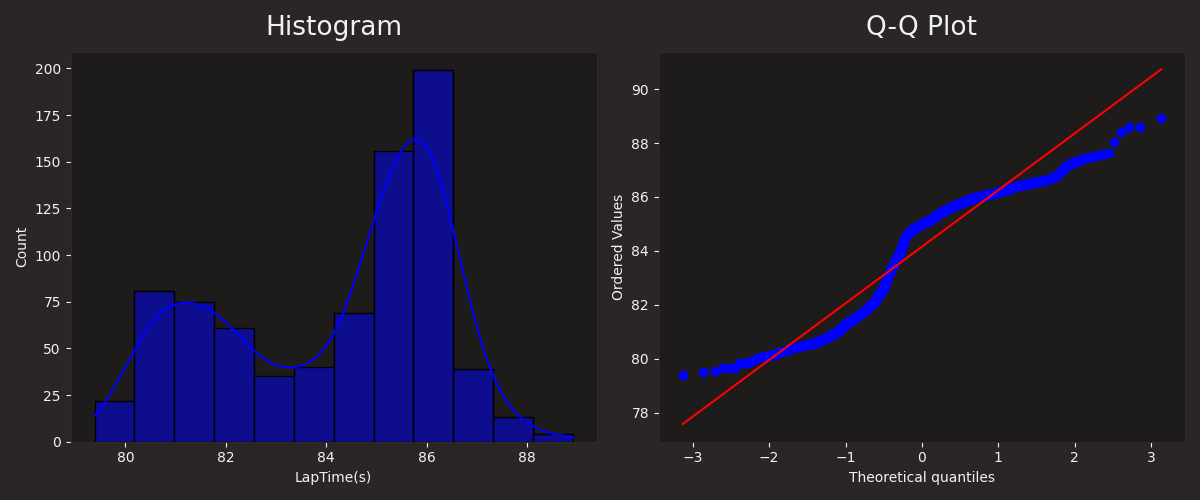

In [20]:
shapiro_wilk_test(all_laps["LapTime(s)"])
plot_normality_visual_inspection(all_laps["LapTime(s)"])

Notice how the data is not normally distributed. This is very common in motorsports, as the cars usually drive very near to the physical limits. We will have to use non-parametric statistical tests for lap time series.

Check how the results change as different compounds are tested:

Test stastic 0.8201
P-Value 0.0000
The data does NOT look normally distributed.


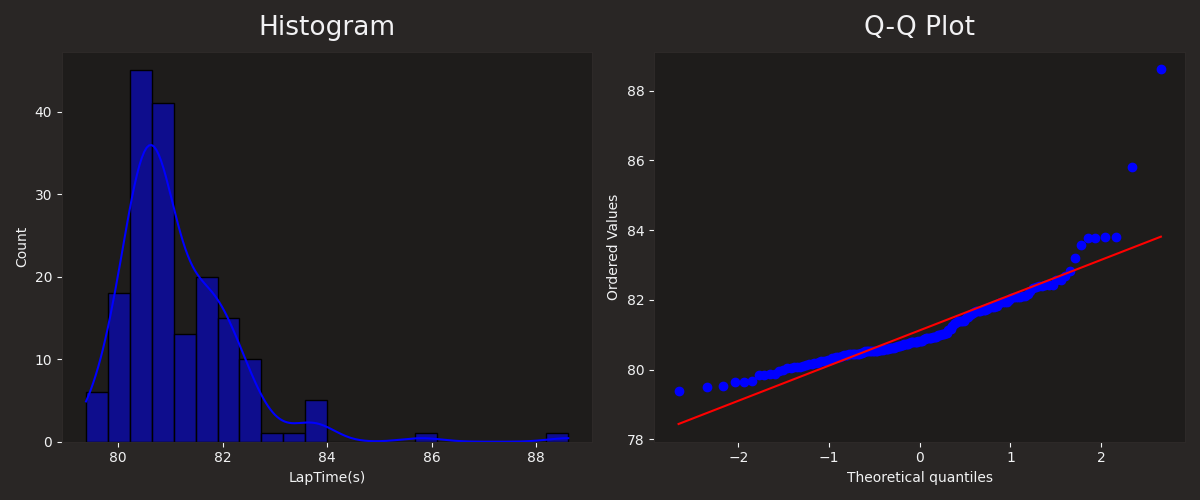

In [21]:
soft = all_laps[all_laps.Compound == "SOFT"]
shapiro_wilk_test(soft["LapTime(s)"])
plot_normality_visual_inspection(soft["LapTime(s)"])

This heavy concentration on the left could be explained by the fact that soft tyres are the ones that bring the cars nearest to the physical limits of speeds for which they have been designed.

Test stastic 0.8689
P-Value 0.0000
The data does NOT look normally distributed.


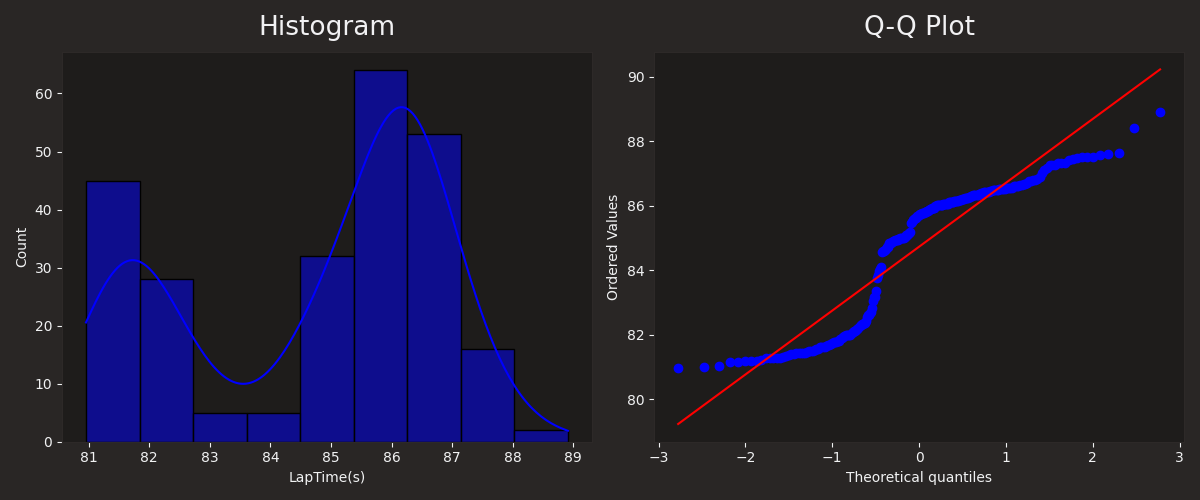

In [22]:
medium = all_laps[all_laps.Compound == "MEDIUM"]
shapiro_wilk_test(medium["LapTime(s)"])
plot_normality_visual_inspection(medium["LapTime(s)"])

Interestingly, there seems to be two different concentrations for hard tires. We will delve deeper into this later.

Test stastic 0.9465
P-Value 0.0000
The data does NOT look normally distributed.


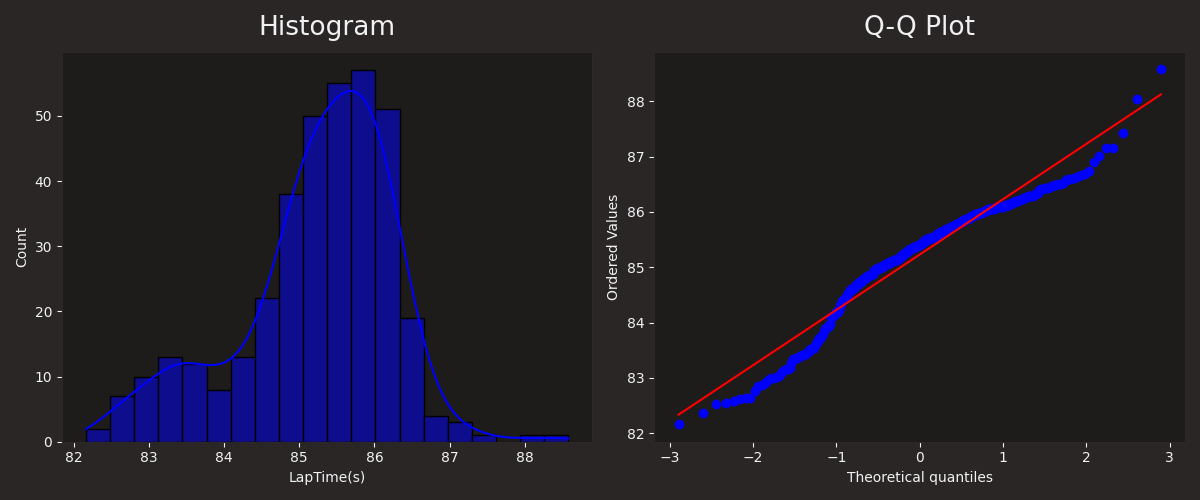

In [23]:
hard = all_laps[all_laps.Compound == "HARD"]
shapiro_wilk_test(hard["LapTime(s)"])
plot_normality_visual_inspection(hard["LapTime(s)"])

However, for hard tyres, while the test still fails, the curve is much more bell-shaped than the others.

## Analyzing Medium Tyre Compound influence on Lap Time

In [24]:
median_order = medium.groupby("Team")["LapTime(s)"].median().sort_values().index

team_palette = {team: ff1.plotting.get_team_color(team, session=quali) for team in median_order}

req            INFO 	Using cached data for driver_info


C:\Users\Vitor\AppData\Local\Temp\ipykernel_25828\2580447405.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["TyreLifeCat"] = pd.cut(data["TyreLife"], bins=bins, labels=labels)
C:\Users\Vitor\AppData\Local\Temp\ipykernel_25828\2580447405.py:23: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(


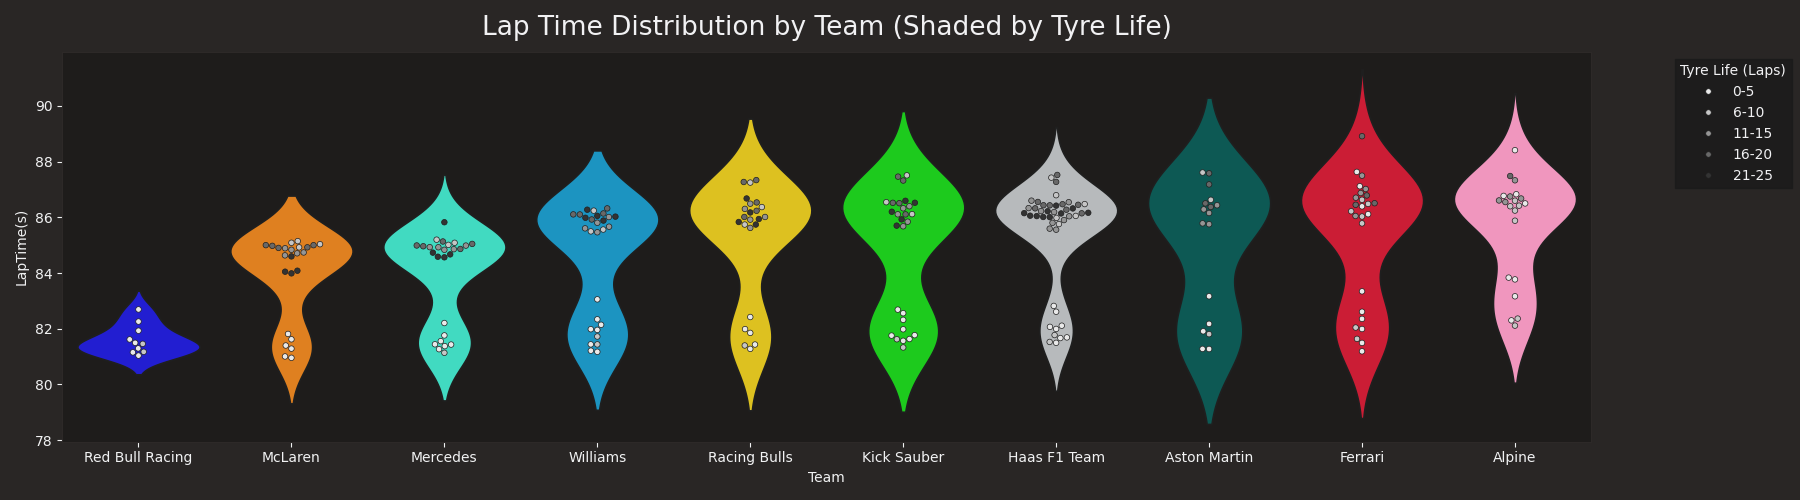

In [25]:
plot_laptime_distribution_by_team_with_tyre_life(medium, quali)

In [26]:
t1_laptimes = medium[medium["Team"] == TEAM_1]["LapTime(s)"]

for position, team in enumerate(median_order):
    if team == TEAM_1:
        continue
    print(f"Comparing against the # {position+1} by median order...")
    team_laptimes = medium[medium["Team"] == team]["LapTime(s)"]
    mann_whitney_u_test(team_laptimes, t1_laptimes)

Comparing against the # 1 by median order...
Test stastic 39.0000
P-Value 0.0023
There is NOT a statistical statistically significant difference between the two series.
Comparing against the # 3 by median order...
Test stastic 340.5000
P-Value 0.5866
There IS a statistical statistically significant difference between the two series.
Comparing against the # 4 by median order...
Test stastic 479.0000
P-Value 0.0089
There is NOT a statistical statistically significant difference between the two series.
Comparing against the # 5 by median order...
Test stastic 460.0000
P-Value 0.0004
There is NOT a statistical statistically significant difference between the two series.
Comparing against the # 6 by median order...
Test stastic 483.0000
P-Value 0.0072
There is NOT a statistical statistically significant difference between the two series.
Comparing against the # 7 by median order...
Test stastic 917.0000
P-Value 0.0000
There is NOT a statistical statistically significant difference between t

This test highlights how complex trying to analyze F1 data is: even between the fastest and the slowest team on the grid, according to the Mann-Whitney U test, it still is not possible to detect a difference between the lap time that is statistically significant.

In [28]:
t1_laptimes = medium[medium["Team"] == TEAM_1]["LapTime(s)"]

for position, team in enumerate(median_order):
    if team == TEAM_1:
        continue
    print(f"Comparing against the # {position+1} by median order...")
    team_laptimes = medium[medium["Team"] == team]["LapTime(s)"]
    ks_test(team_laptimes, t1_laptimes)

Comparing against the # 1 by median order...
D-Statistic (Max gap between distributions): 0.7500
P-Value: 0.0002
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 3 by median order...
D-Statistic (Max gap between distributions): 0.1731
P-Value: 0.7816
Conclusion: No significant difference in distributions (Fail to Reject Null).
Comparing against the # 4 by median order...
D-Statistic (Max gap between distributions): 0.6429
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 5 by median order...
D-Statistic (Max gap between distributions): 0.7500
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 6 by median order...
D-Statistic (Max gap between distributions): 0.6429
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 7 by median order...
D-Statistic (Max gap

Therefore, the main statistical difference between teams lies on consistency rather than overall pace. Keep this in mind as we analyze the race results!

### Tyre Performance Decay

In [29]:
def plot_tyre_decay_scatter_plot(data, kde: bool = False) -> None:
    plt.figure(figsize=(10, 5))

    if kde:
        sns.kdeplot(
            data=data,
            x="TyreLife",
            y="LapTime(s)",
            hue="FreshTyre",
            fill=True,
            alpha=0.3,
            levels=5,
            thresh=0.1,
            legend=False,
        )

    sns.scatterplot(
        data=data,
        x="TyreLife",
        y="LapTime(s)",
        hue="FreshTyre",
        alpha=0.7,
        s=50,
    )

    plt.title("Tyre Degradation: Lap Time vs. Tyre Life (Medium Tyres)", fontsize=14)
    plt.xlabel("Tyre Life (Laps)", fontsize=12)
    plt.ylabel("Lap Time (Seconds)", fontsize=12)

    plt.tight_layout()
    plt.show()

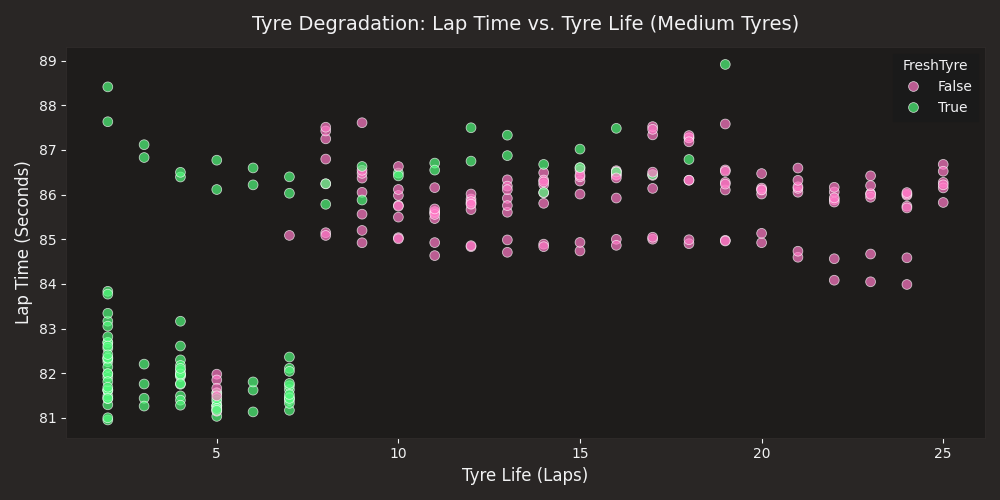

In [30]:
plot_tyre_decay_scatter_plot(medium)

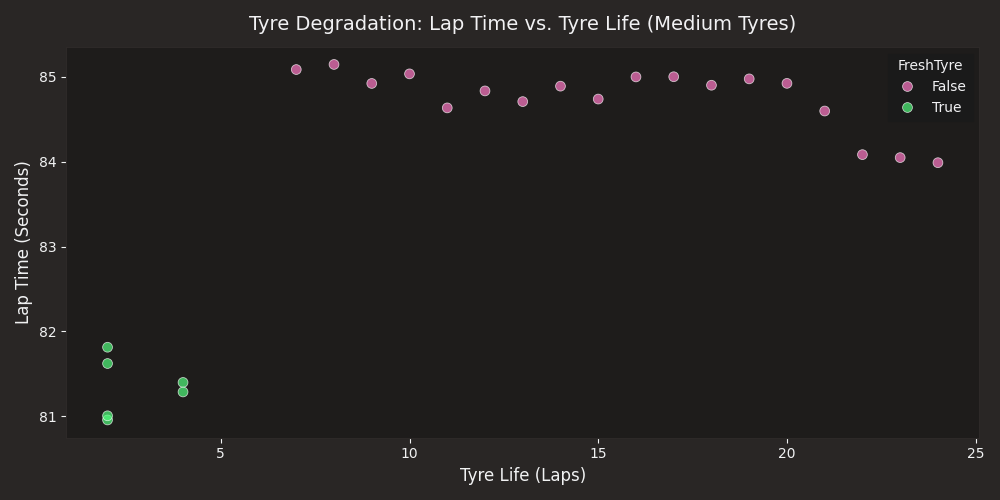

In [31]:
plot_tyre_decay_scatter_plot(medium[medium["Team"] == "McLaren"])

In [32]:
def plot_laptime_correlation_heatmap(data: pd.DataFrame) -> None:
    # 1. Create a copy so we don't accidentally modify the original dataframe
    df_numeric = data.copy()

    # 2. Check if LapTime is a timedelta object. If so, convert to seconds!
    if 'LapTime' in df_numeric.columns and pd.api.types.is_timedelta64_dtype(df_numeric['LapTime']):
        df_numeric['LapTime(s)'] = df_numeric['LapTime'].dt.total_seconds()
        df_numeric = df_numeric.drop(columns=['LapTime'])

    # 3. Filter the dataframe to KEEP ONLY numeric columns
    # This prevents errors from columns like 'Driver', 'Compound', etc.
    df_numeric = df_numeric.select_dtypes(include=['float64', 'int64'])

    # 4. Calculate the correlation matrix
    corr_matrix = df_numeric.corr()

    # 5. Set up the matplotlib figure
    plt.figure(figsize=(12, 10))

    # 6. Draw the heatmap
    sns.heatmap(
        corr_matrix, 
        annot=True,          # Show the actual correlation numbers in the boxes
        cmap='coolwarm',     # Blue for negative, Red for positive correlation
        fmt=".2f",           # Format numbers to 2 decimal places
        vmin=-1, vmax=1,     # Anchor the color scale from -1 to 1
        center=0,            # Ensure 0 (no correlation) is white/neutral
        linewidths=0.5,      # Add lines between squares for readability
        cbar_kws={"shrink": .8} # Slightly shrink the color bar on the right
    )

    plt.title("Formula 1 Telemetry: Correlation Heatmap", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

    # Optional: Print just the LapTime correlations sorted from strongest to weakest
    if 'LapTime(s)' in corr_matrix.columns:
        print("\n--- Correlations with LapTime(s) ---")
        laptime_corr = corr_matrix['LapTime(s)'].sort_values(ascending=False)
        print(laptime_corr.drop('LapTime(s)')) # Drop LapTime correlating with itself (1.0)

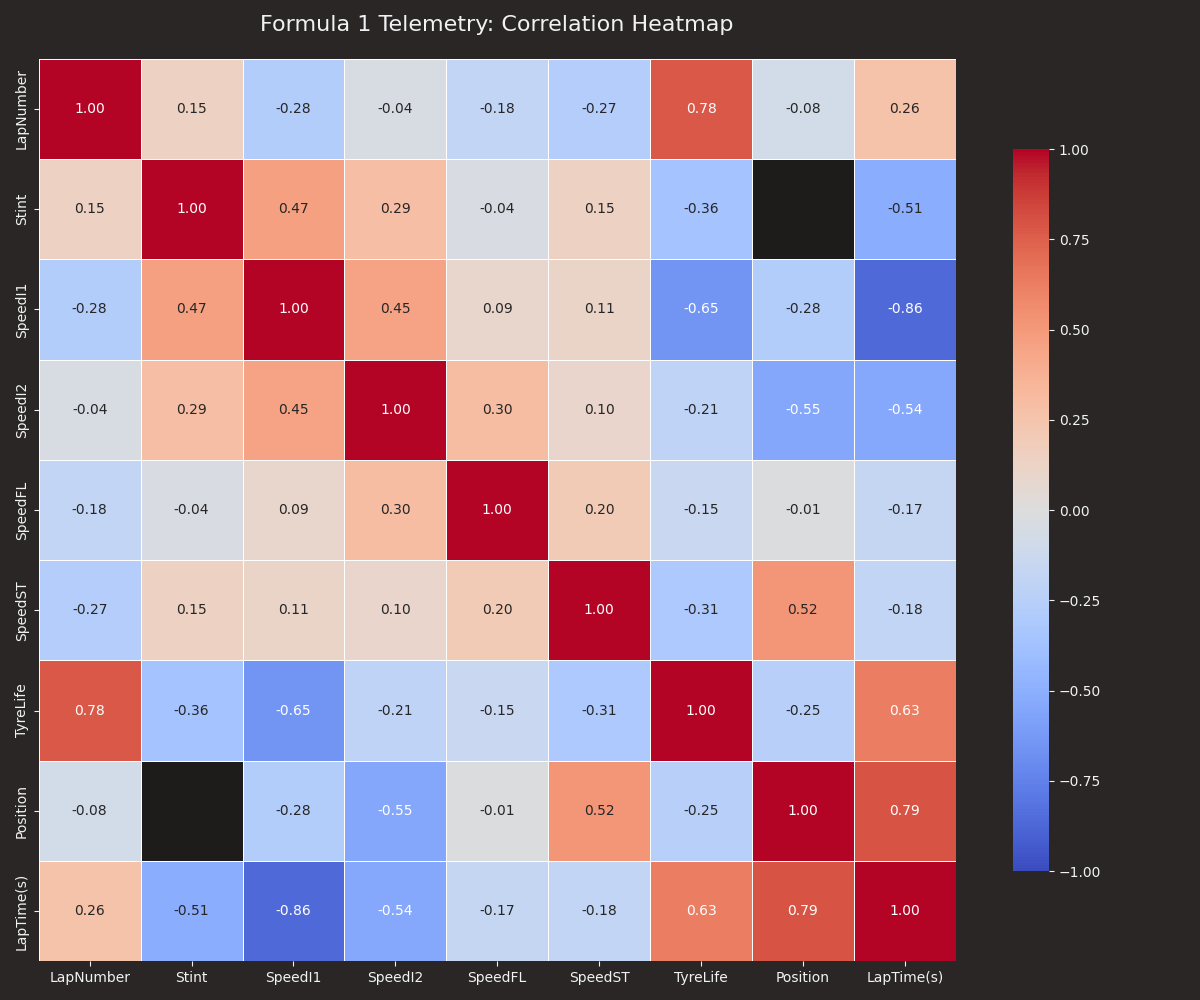


--- Correlations with LapTime(s) ---
Position     0.794034
TyreLife     0.632792
LapNumber    0.260707
SpeedFL     -0.170996
SpeedST     -0.181553
Stint       -0.514510
SpeedI2     -0.544530
SpeedI1     -0.864605
Name: LapTime(s), dtype: float64


In [33]:
plot_laptime_correlation_heatmap(medium)

## Analyzing Hard Tyre Compound influence on LapTime

C:\Users\Vitor\AppData\Local\Temp\ipykernel_25828\2580447405.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["TyreLifeCat"] = pd.cut(data["TyreLife"], bins=bins, labels=labels)
C:\Users\Vitor\AppData\Local\Temp\ipykernel_25828\2580447405.py:23: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(


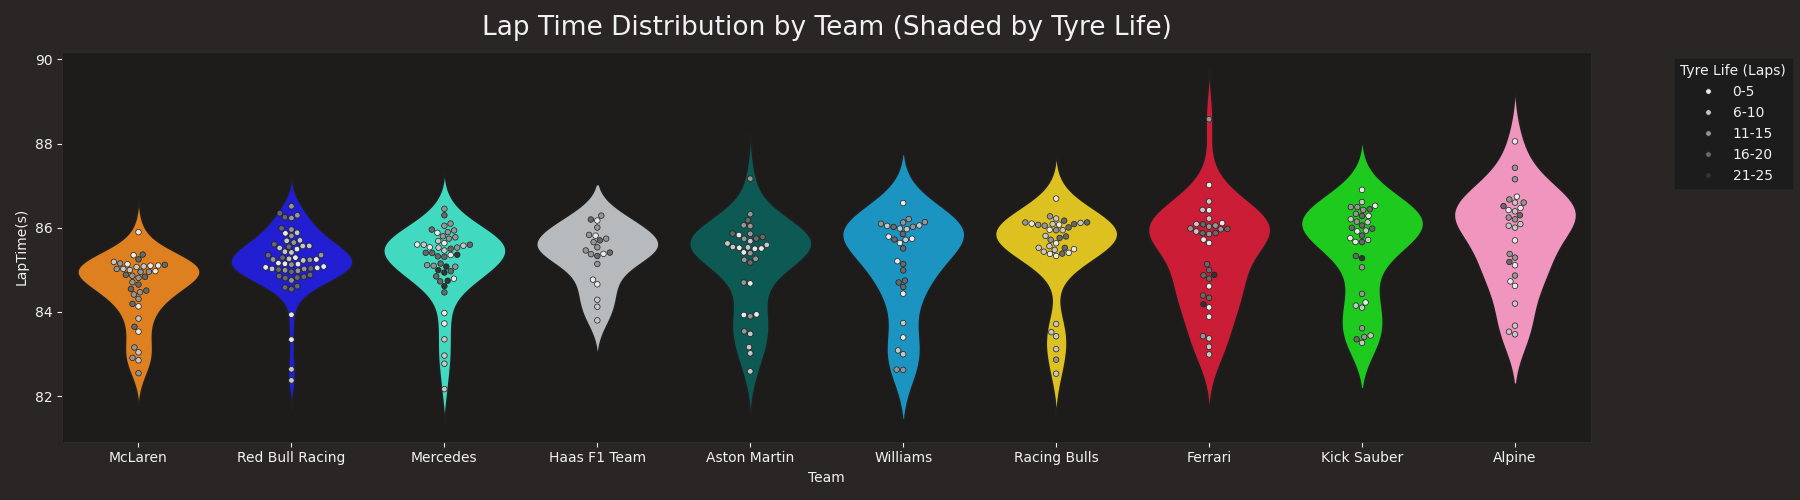

In [34]:
plot_laptime_distribution_by_team_with_tyre_life(hard, quali)

In [35]:
mann_whitney_u_test(medium[medium["Team"] == median_order[0]]["LapTime(s)"], medium[medium["Team"] == median_order[-1]]["LapTime(s)"])

Test stastic 4.0000
P-Value 0.0000
There is NOT a statistical statistically significant difference between the two series.


False

In [40]:
t1_laptimes = hard[hard["Team"] == TEAM_1]["LapTime(s)"]

for position, team in enumerate(median_order):
    if team == TEAM_1:
        continue
    print(f"Comparing against the # {position+1} by median order...")
    team_laptimes = hard[hard["Team"] == team]["LapTime(s)"]
    mann_whitney_u_test(team_laptimes, t1_laptimes)

Comparing against the # 1 by median order...
Test stastic 1684.5000
P-Value 0.0000
There is NOT a statistical statistically significant difference between the two series.
Comparing against the # 3 by median order...
Test stastic 1403.0000
P-Value 0.0001
There is NOT a statistical statistically significant difference between the two series.
Comparing against the # 4 by median order...
Test stastic 868.0000
P-Value 0.0019
There is NOT a statistical statistically significant difference between the two series.
Comparing against the # 5 by median order...
Test stastic 1254.0000
P-Value 0.0000
There is NOT a statistical statistically significant difference between the two series.
Comparing against the # 6 by median order...
Test stastic 1056.0000
P-Value 0.0001
There is NOT a statistical statistically significant difference between the two series.
Comparing against the # 7 by median order...
Test stastic 663.0000
P-Value 0.0001
There is NOT a statistical statistically significant difference 

In [41]:
t1_laptimes = hard[hard["Team"] == TEAM_1]["LapTime(s)"]

for position, team in enumerate(median_order):
    if team == TEAM_1:
        continue
    print(f"Comparing against the # {position+1} by median order...")
    team_laptimes = hard[hard["Team"] == team]["LapTime(s)"]
    ks_test(team_laptimes, t1_laptimes)

Comparing against the # 1 by median order...
D-Statistic (Max gap between distributions): 0.4251
P-Value: 0.0003
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 3 by median order...
D-Statistic (Max gap between distributions): 0.5064
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 4 by median order...
D-Statistic (Max gap between distributions): 0.5550
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 5 by median order...
D-Statistic (Max gap between distributions): 0.7901
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 6 by median order...
D-Statistic (Max gap between distributions): 0.6374
P-Value: 0.0000
Conclusion: The distributions are statistically DIFFERENT (Reject Null).
Comparing against the # 7 by median order...
D-Statistic (Max gap betw

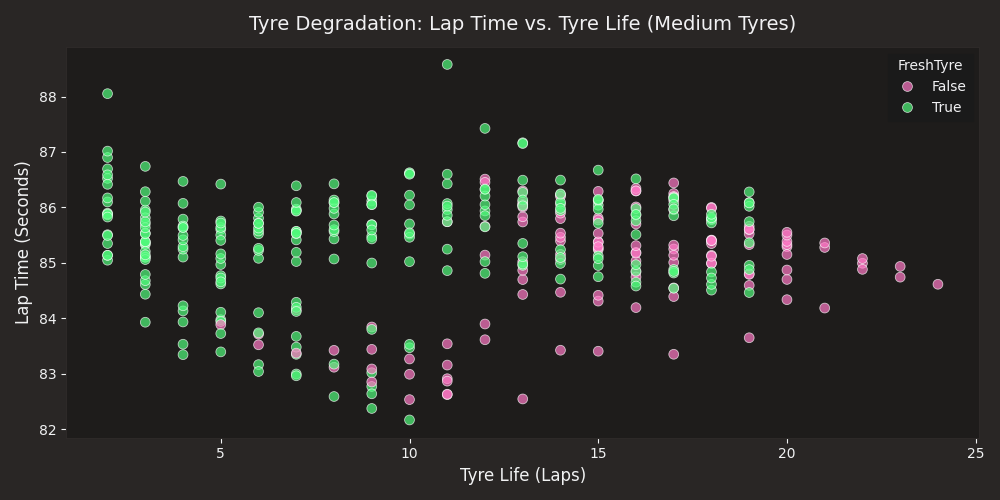

In [36]:
plot_tyre_decay_scatter_plot(hard)

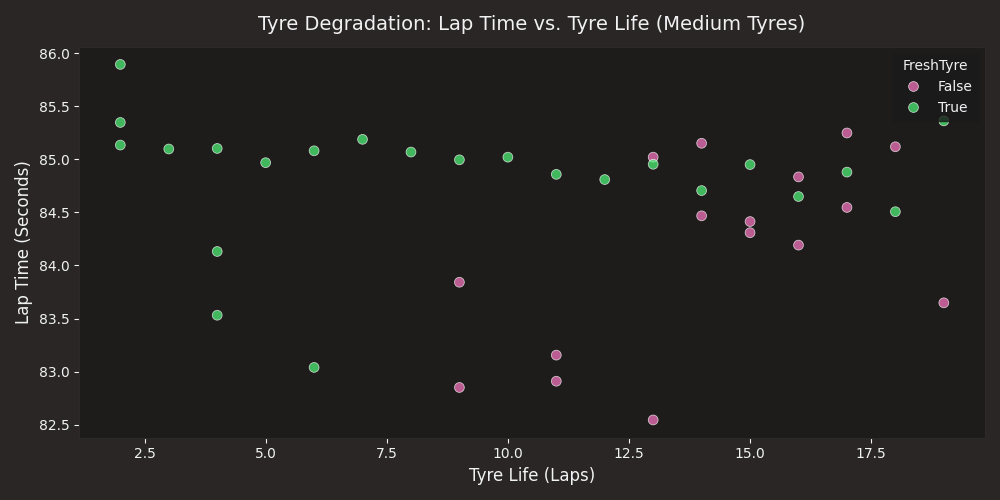

In [37]:
plot_tyre_decay_scatter_plot(hard[hard["Team"] == "McLaren"])

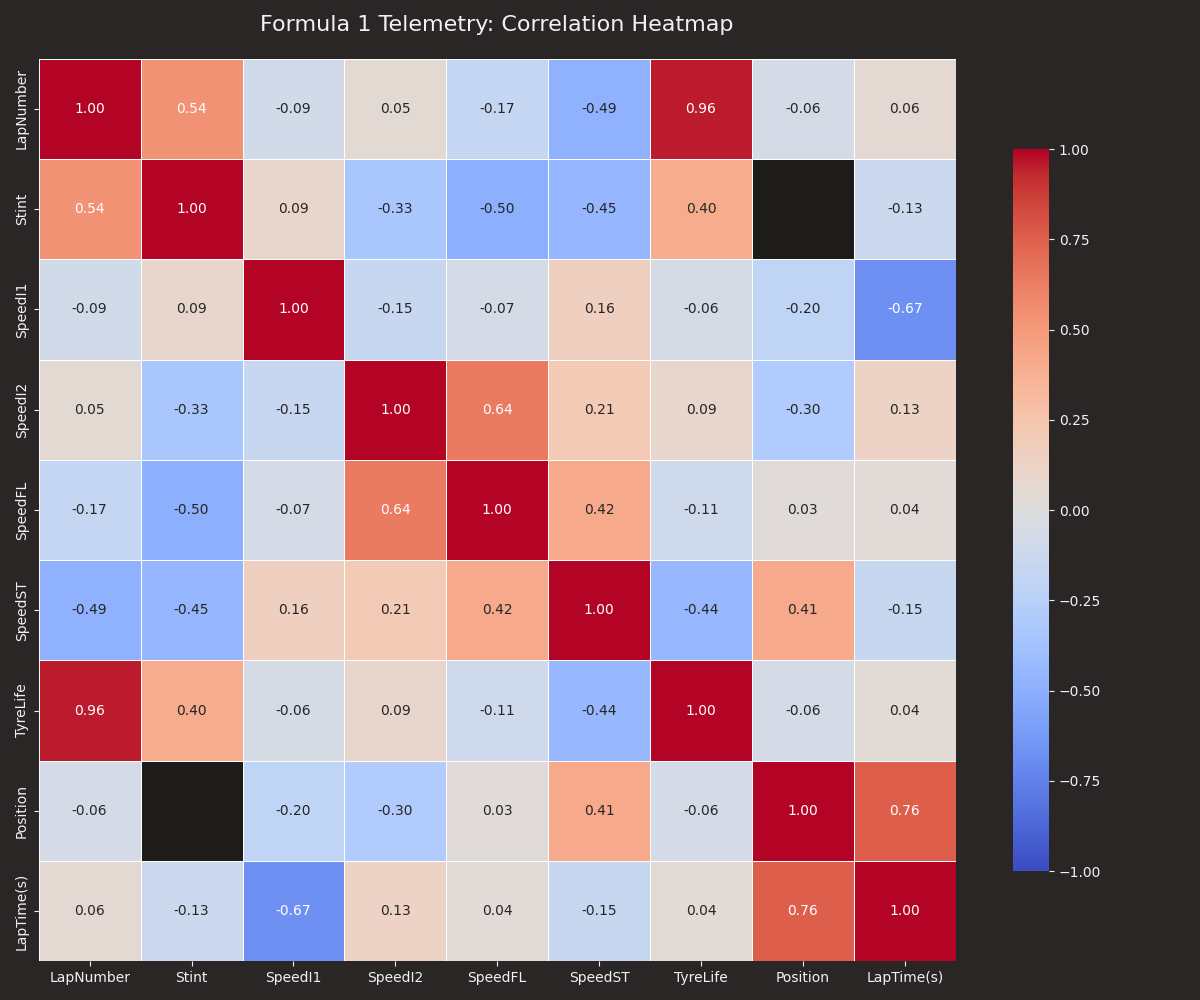


--- Correlations with LapTime(s) ---
Position     0.756029
SpeedI2      0.126398
LapNumber    0.060090
TyreLife     0.040247
SpeedFL      0.037757
Stint       -0.129123
SpeedST     -0.152722
SpeedI1     -0.672681
Name: LapTime(s), dtype: float64


In [38]:
plot_laptime_correlation_heatmap(hard)